# Aquila Statistics Dashboard

Fetches and visualizes consumption, billing and matching-quality statistics from the Aquila case database.

**Customer:** System Air (single tenant — the schema has no client table, so the breakdown dimension is `"user"` + `user_role`)
**Billing model:** pay-as-you-go in **EUR** — `billable_items × 0.035 EUR` **+ 650 EUR** mandatory monthly Azure Cloud Infrastructure fee (no tiers, no monthly minimum). CZK figures are derived via `EUR_TO_CZK_CURRECY_RATE`.
**Billable item:** `case_item.status_id IN (2 MATCHED, 4 MATCH_NOT_FOUND, 5 PAIRED)`, attributed to a period by its parent `"case".created_at`

**Excluded accounts:** 5 internal/test `user_id`s are filtered out of every query (see `EXCLUDED_USER_IDS`).

## Sections
1. **Setup** — packages, DB connection, config
2. **Current Month Summary** — billable items, item charges per user, Azure fee, invoice total
3. **Month-over-Month Growth** — items and revenue growth %
4. **Consumption Trend** — line chart per user
5. **Cumulative YTD** — running total incl. the monthly Azure fee
6. **Daily Volume Heatmap** — billable items by day
7. **Case Efficiency** — items per case
8. **Pareto / Top Users** — 80/20 volume analysis
9. **Item Status Distribution** — what share of items is actually billed
10. **Matching Quality** — pair rate, no-match rate, exact dimensions
11. **Case State Funnel** — uploads reaching a terminal state
12. **Processing Latency** — parse & processing time percentiles
13. **Offer Depth & Match Distance** — candidates per item, quality of the pick
14. **Accessory Attach Rate** — upsell signal
15. **Export to PDF**


## 1. Setup

In [1]:
# Uncomment on first run
# !pip install psycopg2-binary pandas matplotlib seaborn

In [2]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import date

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [3]:
# ── SECRETS ──────────────────────────────────────────────────
# Loaded from the .env file in THIS project folder (git-ignored).
# First run:  cp .env.example .env  and fill it in.
# Start Jupyter from this folder so the kernel's working directory matches.
import os
from pathlib import Path

from dotenv import load_dotenv

ENV_PATH = Path.cwd() / '.env'
if not ENV_PATH.is_file():
    raise RuntimeError(
        f'No .env found at {ENV_PATH}. Copy .env.example to .env in this '
        f'project folder and fill it in (and start Jupyter from this folder).'
    )
load_dotenv(ENV_PATH)


def env(name, default=None, required=True):
    """Read a setting from this folder's .env / the environment."""
    val = os.getenv(name, default)
    if required and not val:
        raise RuntimeError(
            f'Missing required setting: {name}. Add it to {ENV_PATH} '
            f'(see .env.example).'
        )
    return val

# ── DB CONFIG ────────────────────────────────────────────
DB = dict(
    host     = env('AQUILA_DB_HOST'),
    port     = int(env('AQUILA_DB_PORT', 5432)),
    dbname   = env('AQUILA_DB_NAME'),
    user     = env('AQUILA_DB_USER'),
    password = env('AQUILA_DB_PASSWORD'),
    sslmode  = env('AQUILA_DB_SSLMODE', 'require'),
)

# ── REPORT PERIOD ───────────────────────────────────────
# REPORT_YEAR  = date.today().year
# REPORT_MONTH = date.today().month

REPORT_YEAR  = 2026
REPORT_MONTH = 9

# Half-open period [PERIOD_FROM, PERIOD_TO) — a case created at exactly
# midnight on the 1st belongs to the month that starts, not the one that ends.
PERIOD_FROM = date(REPORT_YEAR, REPORT_MONTH, 1)
PERIOD_TO   = date(REPORT_YEAR + (REPORT_MONTH // 12), (REPORT_MONTH % 12) + 1, 1)

# ── BILLING DEFINITION ───────────────────────────────────
# 2=MATCHED, 4=MATCH_NOT_FOUND, 5=PAIRED
BILLABLE_STATUSES = (2, 4, 5)
BILLABLE = 'i.status_id IN (2, 4, 5)'

# ── PRICING (EUR is the billing currency) ────────────────
UNIT_PRICE_EUR          = 0.035   # EUR per billable item
AZURE_INFRA_FEE_EUR     = 650.0   # mandatory monthly Azure Cloud Infrastructure fee
EUR_TO_CZK_CURRECY_RATE = 25.0    # TODO: confirm the contractual EUR → CZK rate

# The Azure fee is ONE mandatory charge per MONTH for the whole customer
# (System Air) — it is never split across the per-user rows. Per-user amounts
# below are item charges only; the fee is added once at the monthly total.
#
#   monthly_total_eur = billable_items * UNIT_PRICE_EUR + AZURE_INFRA_FEE_EUR
#   monthly_total_czk = monthly_total_eur * EUR_TO_CZK_CURRECY_RATE

# The supplied billing query does NOT filter is_deleted — deleted items and
# cases are still billed. Set to False to exclude them (changes invoiced totals).
INCLUDE_DELETED = True
ITEM_DELETED_FILTER = '' if INCLUDE_DELETED else 'AND i.is_deleted = FALSE'
CASE_DELETED_FILTER = '' if INCLUDE_DELETED else 'AND c.is_deleted = FALSE'

# ── EXCLUDED USERS ──────────────────────────────────────
# These accounts are excluded COMPLETELY from every query below —
# internal/test accounts that must not appear in stats or billing.
EXCLUDED_USER_IDS = (
    '88bcefe9-b2c8-44de-ba8b-49853f9b0d3b',
    'a997e479-9df4-44de-a9ef-bc10ce8376f7',
    '0954b909-1130-4f94-af06-00193783ce31',
    '5b9f2bbf-f5bf-4df0-a007-653e8c6a34e9',
    '0e862f6c-3661-46d5-a951-28b2f7d39ca2',
)

# NB: a bare `c.user_id NOT IN (...)` would also drop cases with a NULL
# user_id (NULL NOT IN (...) evaluates to NULL, not TRUE). Those accounts are
# not on the exclusion list, so they are kept explicitly.
USER_FILTER = ('AND (c.user_id IS NULL OR c.user_id NOT IN ('
               + ', '.join(f"'{u}'::uuid" for u in EXCLUDED_USER_IDS) + '))')

# ── CASE / ITEM STATE NAMES ─────────────────────────────────
CASE_STATES = {
    1: 'OPENED', 2: 'PARSED', 3: 'NOT_PARSED', 4: 'FAILED',
    5: 'PROCESSED', 6: 'EXPORTED', 7: 'NOT_EXPORTED', 8: 'DROPPED',
}
ITEM_STATUSES = {
    1: 'CREATED', 2: 'MATCHED', 3: 'NOT_MATCHED',
    4: 'MATCH_NOT_FOUND', 5: 'PAIRED',
}
# "Settled" cases per the agreed definition. NB: this band includes
# FAILED (4) and DROPPED (8) — it is not a success rate.
SETTLED_MIN_STATE    = 4
SETTLED_STATE_FILTER = f'c.state_id >= {SETTLED_MIN_STATE}'

# ── SHARED SQL SNIPPET ──────────────────────────────────
USER_NAME = "COALESCE(NULLIF(TRIM(u.first_name || ' ' || u.last_name), ''), u.email, '(unknown user)')"

print(f'Report period:  {REPORT_YEAR}-{REPORT_MONTH:02d}  [{PERIOD_FROM} → {PERIOD_TO})')
print(f'Billable items: {BILLABLE}')
print(f'Unit price:     {UNIT_PRICE_EUR} EUR / item')
print(f'Azure fee:      {AZURE_INFRA_FEE_EUR:,.2f} EUR / month (mandatory, customer-wide)')
print(f'FX rate:        1 EUR = {EUR_TO_CZK_CURRECY_RATE} CZK')
print(f'Deleted rows:   {"INCLUDED (matches supplied billing query)" if INCLUDE_DELETED else "EXCLUDED"}')
print(f'Excluded users: {len(EXCLUDED_USER_IDS)} account(s) removed from every query')

Report period:  2026-09  [2026-09-01 → 2026-10-01)
Billable items: i.status_id IN (2, 4, 5)
Unit price:     0.035 EUR / item
Azure fee:      650.00 EUR / month (mandatory, customer-wide)
FX rate:        1 EUR = 25.0 CZK
Deleted rows:   INCLUDED (matches supplied billing query)
Excluded users: 5 account(s) removed from every query


In [4]:
def query(sql, params=None):
    with psycopg2.connect(**DB) as conn:
        with conn.cursor() as cur:
            cur.execute(sql, params)
            cols = [desc.name for desc in cur.description]
            return pd.DataFrame(cur.fetchall(), columns=cols)


PERIOD = {'period_from': PERIOD_FROM, 'period_to': PERIOD_TO}

## 2. Current Month Summary

In [5]:
SQL_MONTHLY_SUMMARY = f"""
WITH billable AS (
    SELECT
        c.case_id,
        i.item_id,
        {USER_NAME} AS user_name,
        COALESCE(ur.role_name, '(none)') AS role_name
    FROM case_item i
    INNER JOIN "case"    c  ON c.case_id = i.case_id
    LEFT  JOIN "user"    u  ON u.user_id = c.user_id
    LEFT  JOIN user_role ur ON ur.role_id = u.role_id
    WHERE {BILLABLE}
      AND c.created_at >= %(period_from)s
      AND c.created_at <  %(period_to)s
      {ITEM_DELETED_FILTER}
      {CASE_DELETED_FILTER}
      {USER_FILTER}
)
SELECT
    user_name,
    role_name,
    COUNT(DISTINCT case_id)                              AS cases,
    COUNT(item_id)                                       AS billable_items,
    ROUND(COUNT(item_id) * {UNIT_PRICE_EUR}::numeric, 2) AS amount_eur
FROM billable
GROUP BY user_name, role_name
ORDER BY user_name;
"""

# Per-user rows carry item charges only — the Azure fee is customer-wide.
df_users = query(SQL_MONTHLY_SUMMARY, PERIOD)
df_users['amount_eur'] = pd.to_numeric(df_users['amount_eur'], errors='coerce')

# Charge off the raw item count, NOT the sum of per-user rounded amounts —
# otherwise per-user rounding leaks into the invoice total (e.g. 5.79 vs 5.78).
total_items = int(df_users['billable_items'].sum())
items_eur   = round(total_items * UNIT_PRICE_EUR, 2)
total_eur   = round(items_eur + AZURE_INFRA_FEE_EUR, 2)

# Build the invoice table: per-user rows + subtotal + Azure fee + grand total
footer = pd.DataFrame([
    {'user_name': 'ZZ SUBTOTAL (items)',    'role_name': '',
     'cases': df_users['cases'].sum(), 'billable_items': df_users['billable_items'].sum(),
     'amount_eur': items_eur},
    {'user_name': 'ZZ AZURE INFRA FEE',     'role_name': '',
     'cases': None, 'billable_items': None, 'amount_eur': AZURE_INFRA_FEE_EUR},
    {'user_name': 'ZZ TOTAL',               'role_name': '',
     'cases': df_users['cases'].sum(), 'billable_items': df_users['billable_items'].sum(),
     'amount_eur': total_eur},
])

df_summary = pd.concat([df_users, footer], ignore_index=True)
df_summary['amount_czk'] = (df_summary['amount_eur'] * EUR_TO_CZK_CURRECY_RATE).round(2)

print(f'Items:  {df_users["billable_items"].sum():,} × {UNIT_PRICE_EUR} EUR = {items_eur:,.2f} EUR')
print(f'Azure:  {AZURE_INFRA_FEE_EUR:,.2f} EUR')
print(f'TOTAL:  {total_eur:,.2f} EUR = {total_eur * EUR_TO_CZK_CURRECY_RATE:,.2f} CZK')
df_summary

Items:  679 × 0.035 EUR = 23.77 EUR
Azure:  650.00 EUR
TOTAL:  673.77 EUR = 16,844.25 CZK


,user_name,role_name,cases,billable_items,amount_eur,amount_czk
0,Gabriela Kapicová,USER,1.0,33.0,1.16,29.00
1,Libor Lička,ADMIN,4.0,157.0,5.50,137.50
2,Ondřej Pichl,ADMIN,4.0,69.0,2.42,60.50
3,Silvie Adamčíková,USER,4.0,354.0,12.39,309.75
4,Tereza Čtvrtlíková,USER,1.0,66.0,2.31,57.75
5,ZZ SUBTOTAL (items),,14.0,679.0,23.77,594.25
6,ZZ AZURE INFRA FEE,,NaN,NaN,650.00,16250.00
7,ZZ TOTAL,,14.0,679.0,673.77,16844.25


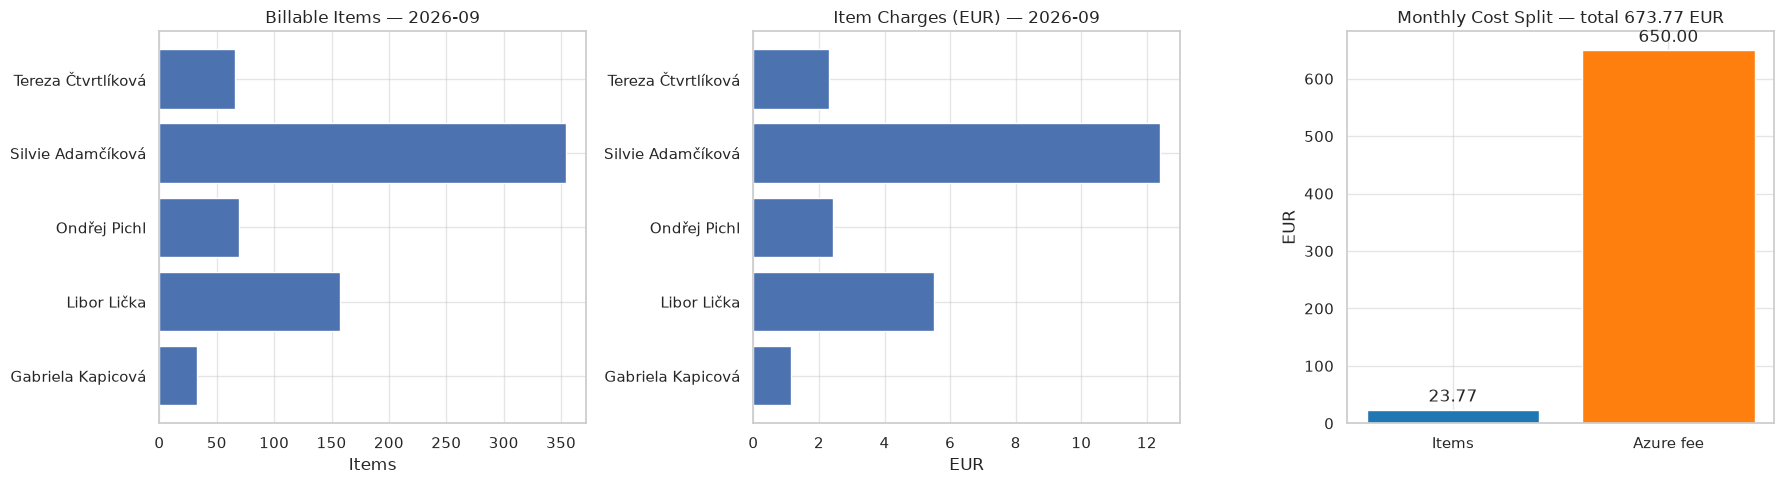

In [6]:
users = df_summary[~df_summary.user_name.str.startswith('ZZ ')].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(users.user_name, users.billable_items)
axes[0].set_title(f'Billable Items — {REPORT_YEAR}-{REPORT_MONTH:02d}')
axes[0].set_xlabel('Items')

axes[1].barh(users.user_name, users.amount_eur)
axes[1].set_title(f'Item Charges (EUR) — {REPORT_YEAR}-{REPORT_MONTH:02d}')
axes[1].set_xlabel('EUR')

# Cost split: item charges vs the fixed Azure fee
axes[2].bar(['Items', 'Azure fee'], [items_eur, AZURE_INFRA_FEE_EUR],
            color=['tab:blue', 'tab:orange'])
axes[2].bar_label(axes[2].containers[0], fmt='%.2f', padding=3)
axes[2].set_title(f'Monthly Cost Split — total {total_eur:,.2f} EUR')
axes[2].set_ylabel('EUR')

plt.tight_layout()
plt.show()

## 3. Month-over-Month Growth

In [7]:
SQL_MOM = f"""
WITH billable AS (
    SELECT
        {USER_NAME}                       AS user_name,
        DATE_TRUNC('month', c.created_at) AS month,
        c.case_id,
        i.item_id
    FROM case_item i
    INNER JOIN "case" c ON c.case_id = i.case_id
    LEFT  JOIN "user" u ON u.user_id = c.user_id
    WHERE {BILLABLE}
      {ITEM_DELETED_FILTER}
      {CASE_DELETED_FILTER}
      {USER_FILTER}
),
monthly_per_user AS (
    SELECT
        user_name,
        month,
        COUNT(DISTINCT case_id)                              AS cases,
        COUNT(item_id)                                       AS billable_items,
        ROUND(COUNT(item_id) * {UNIT_PRICE_EUR}::numeric, 2) AS amount_eur
    FROM billable
    GROUP BY user_name, month
)
SELECT
    user_name,
    month,
    cases,
    billable_items,
    amount_eur,
    LAG(billable_items) OVER (PARTITION BY user_name ORDER BY month) AS prev_month_items,
    LAG(amount_eur)     OVER (PARTITION BY user_name ORDER BY month) AS prev_month_amount_eur,
    ROUND((billable_items - LAG(billable_items) OVER (PARTITION BY user_name ORDER BY month))
        * 100.0 / NULLIF(LAG(billable_items) OVER (PARTITION BY user_name ORDER BY month), 0), 1)
        AS items_growth_pct,
    ROUND((amount_eur - LAG(amount_eur) OVER (PARTITION BY user_name ORDER BY month))
        * 100.0 / NULLIF(LAG(amount_eur) OVER (PARTITION BY user_name ORDER BY month), 0), 1)
        AS revenue_growth_pct
FROM monthly_per_user
ORDER BY user_name, month;
"""

df_mom = query(SQL_MOM)
df_mom['month'] = pd.to_datetime(df_mom['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_mom['items_growth_pct']   = pd.to_numeric(df_mom['items_growth_pct'],   errors='coerce')
df_mom['revenue_growth_pct'] = pd.to_numeric(df_mom['revenue_growth_pct'], errors='coerce')
df_mom.tail(20)

,user_name,month,cases,billable_items,amount_eur,prev_month_items,prev_month_amount_eur,items_growth_pct,revenue_growth_pct
9,Libor Lička,2026-07-01,3,502,17.57,72.0,2.52,597.2,597.2
10,Libor Lička,2026-08-01,2,43,1.51,502.0,17.57,-91.4,-91.4
11,Libor Lička,2026-09-01,4,157,5.50,43.0,1.51,265.1,264.2
12,Marian Musiolek,2026-08-01,2,360,12.60,NaN,None,NaN,NaN
13,Ondřej Hývnar,2026-04-01,3,27,0.95,NaN,None,NaN,NaN
14,Ondřej Pichl,2026-04-01,3,1349,47.22,NaN,None,NaN,NaN
15,Ondřej Pichl,2026-05-01,7,507,17.75,1349.0,47.22,-62.4,-62.4
16,Ondřej Pichl,2026-06-01,8,393,13.76,507.0,17.75,-22.5,-22.5
17,Ondřej Pichl,2026-07-01,2,6,0.21,393.0,13.76,-98.5,-98.5
18,Ondřej Pichl,2026-08-01,11,267,9.35,6.0,0.21,4350.0,4352.4


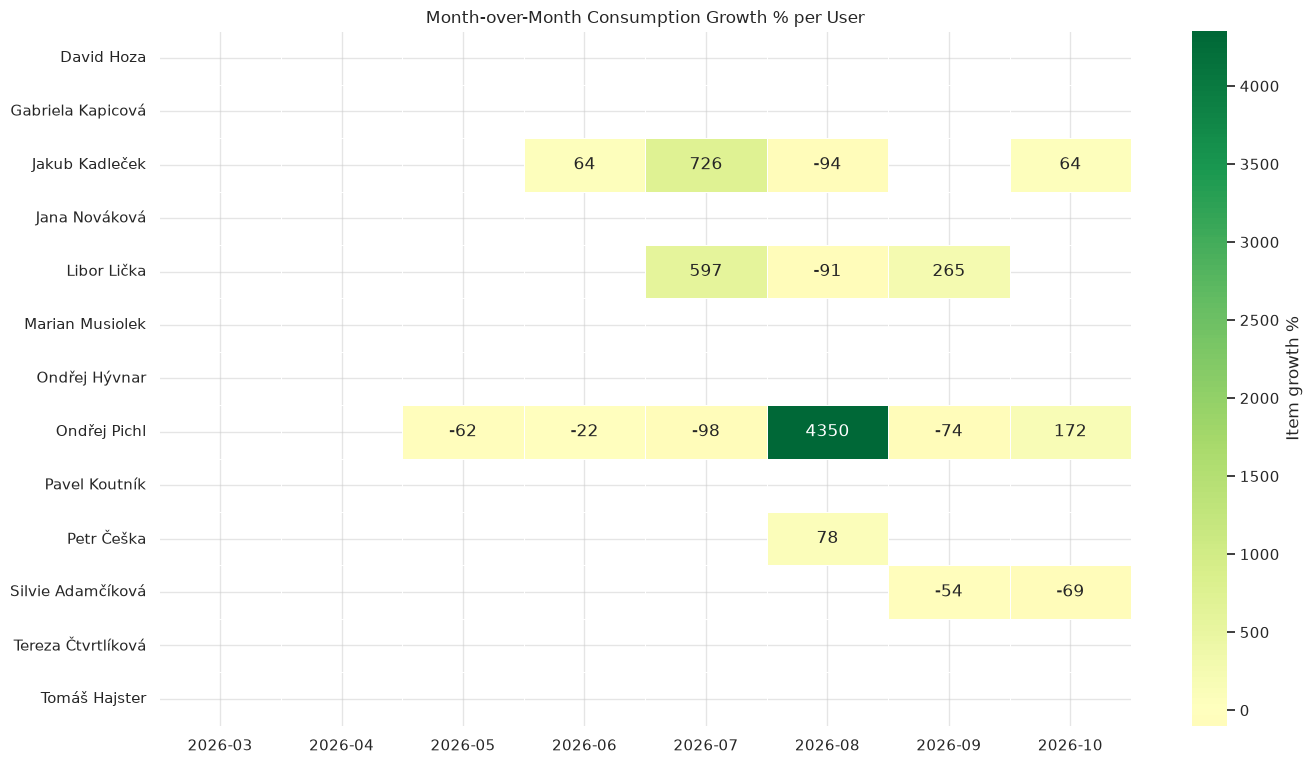

In [8]:
# Heatmap: item growth % by user × month
# (with flat pay-as-you-go pricing, revenue growth % == item growth %)
pivot_mom = df_mom.pivot(index='user_name', columns='month', values='items_growth_pct')
pivot_mom.columns = pivot_mom.columns.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(14, max(4, len(pivot_mom) * 0.6)))
sns.heatmap(
    pivot_mom.astype(float), annot=True, fmt='.0f', center=0, cmap='RdYlGn',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Item growth %'}
)
ax.set_title('Month-over-Month Consumption Growth % per User')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 4. Consumption Trend (line chart per user)

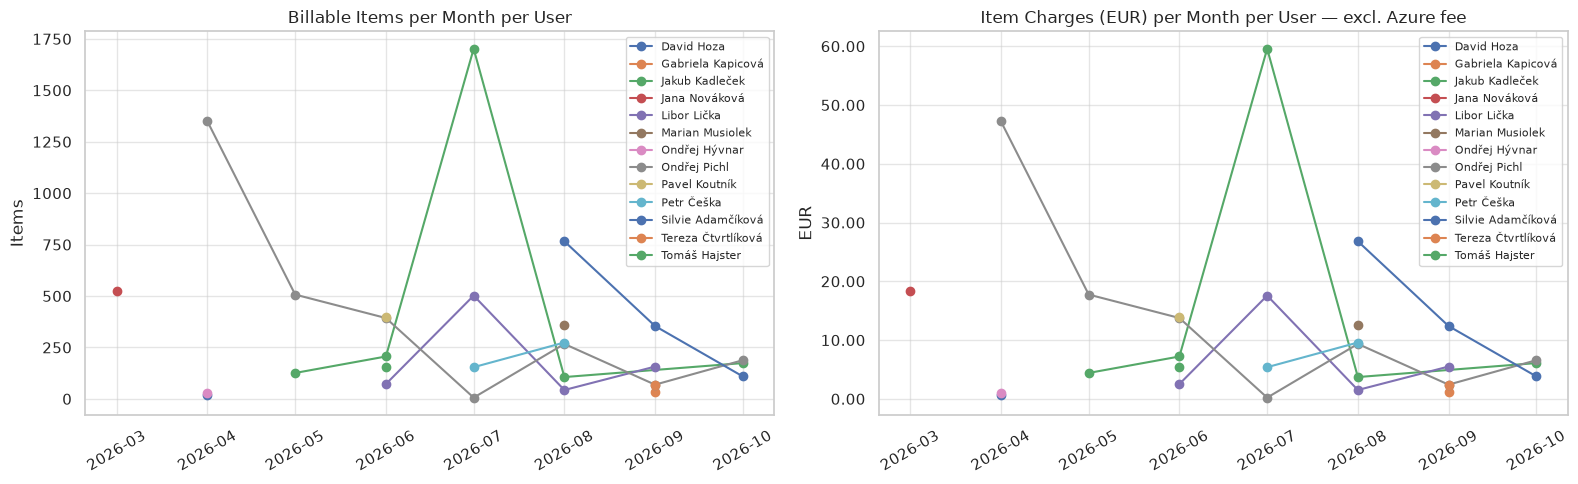

In [9]:
SQL_TREND = f"""
SELECT
    {USER_NAME}                                      AS user_name,
    DATE_TRUNC('month', c.created_at)                AS month,
    COUNT(DISTINCT c.case_id)                        AS cases,
    COUNT(i.item_id)                                     AS billable_items,
    ROUND(COUNT(i.item_id) * {UNIT_PRICE_EUR}::numeric, 2) AS amount_eur
FROM case_item i
INNER JOIN "case" c ON c.case_id = i.case_id
LEFT  JOIN "user" u ON u.user_id = c.user_id
WHERE {BILLABLE}
  {ITEM_DELETED_FILTER}
  {CASE_DELETED_FILTER}
  {USER_FILTER}
GROUP BY user_name, DATE_TRUNC('month', c.created_at)
ORDER BY month, user_name;
"""

df_trend = query(SQL_TREND)
df_trend['month'] = pd.to_datetime(df_trend['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_trend['amount_eur'] = pd.to_numeric(df_trend['amount_eur'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for user, grp in df_trend.groupby('user_name'):
    axes[0].plot(grp['month'], grp['billable_items'], marker='o', label=user)
    axes[1].plot(grp['month'], grp['amount_eur'],     marker='o', label=user)
axes[0].set_title('Billable Items per Month per User'); axes[0].set_ylabel('Items'); axes[0].legend(fontsize=8)
axes[1].set_title('Item Charges (EUR) per Month per User — excl. Azure fee'); axes[1].set_ylabel('EUR')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.2f}')); axes[1].legend(fontsize=8)
for ax in axes: ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 5. Cumulative YTD Consumption

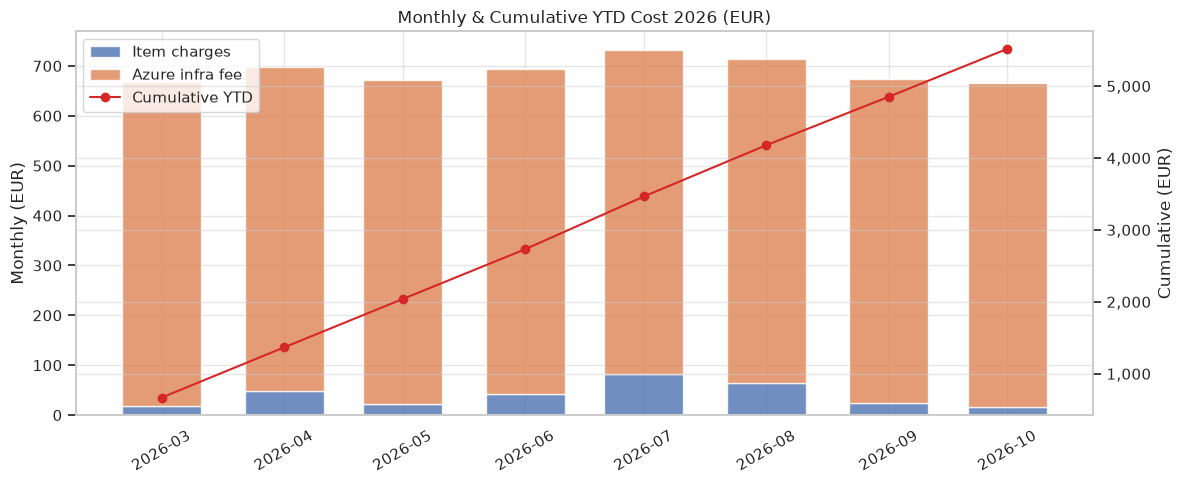

,month,billable_items,items_amount_eur,azure_fee_eur,total_eur,total_czk,cumulative_eur,cumulative_czk
0,2026-03-01,525,18.38,650.0,668.38,16709.50,668.38,16709.50
1,2026-04-01,1394,48.79,650.0,698.79,17469.75,1367.17,34179.25
2,2026-05-01,633,22.16,650.0,672.16,16804.00,2039.33,50983.25
3,2026-06-01,1226,42.91,650.0,692.91,17322.75,2732.24,68306.00
4,2026-07-01,2364,82.74,650.0,732.74,18318.50,3464.98,86624.50
5,2026-08-01,1816,63.56,650.0,713.56,17839.00,4178.54,104463.50
6,2026-09-01,679,23.77,650.0,673.77,16844.25,4852.31,121307.75
7,2026-10-01,471,16.49,650.0,666.49,16662.25,5518.80,137970.00


In [10]:
SQL_CUMULATIVE = f"""
SELECT
    DATE_TRUNC('month', c.created_at)                     AS month,
    COUNT(i.item_id)                                      AS billable_items,
    ROUND(COUNT(i.item_id) * {UNIT_PRICE_EUR}::numeric, 2) AS items_amount_eur
FROM case_item i
INNER JOIN "case" c ON c.case_id = i.case_id
WHERE {BILLABLE}
  AND EXTRACT(YEAR FROM c.created_at) = %(year)s
  {ITEM_DELETED_FILTER}
  {CASE_DELETED_FILTER}
  {USER_FILTER}
GROUP BY DATE_TRUNC('month', c.created_at)
ORDER BY month;
"""

df_cum = query(SQL_CUMULATIVE, {'year': REPORT_YEAR})
df_cum['month'] = pd.to_datetime(df_cum['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_cum['items_amount_eur'] = pd.to_numeric(df_cum['items_amount_eur'], errors='coerce')

# The Azure fee is charged once per month the customer is active
df_cum['azure_fee_eur']    = AZURE_INFRA_FEE_EUR
df_cum['total_eur']        = df_cum['items_amount_eur'] + df_cum['azure_fee_eur']
df_cum['total_czk']        = (df_cum['total_eur'] * EUR_TO_CZK_CURRECY_RATE).round(2)
df_cum['cumulative_items'] = df_cum['billable_items'].cumsum()
df_cum['cumulative_eur']   = df_cum['total_eur'].cumsum().round(2)
df_cum['cumulative_czk']   = df_cum['total_czk'].cumsum().round(2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_cum['month'], df_cum['items_amount_eur'], width=20, alpha=0.8, label='Item charges')
ax.bar(df_cum['month'], df_cum['azure_fee_eur'], width=20, alpha=0.8,
       bottom=df_cum['items_amount_eur'], label='Azure infra fee')
ax2 = ax.twinx()
ax2.plot(df_cum['month'], df_cum['cumulative_eur'], color='tab:red', marker='o', label='Cumulative YTD')
ax.set_title(f'Monthly & Cumulative YTD Cost {REPORT_YEAR} (EUR)')
ax.set_ylabel('Monthly (EUR)'); ax2.set_ylabel('Cumulative (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=30)
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left')
plt.tight_layout(); plt.show()
df_cum[['month', 'billable_items', 'items_amount_eur', 'azure_fee_eur',
        'total_eur', 'total_czk', 'cumulative_eur', 'cumulative_czk']]

## 6. Daily Volume Heatmap

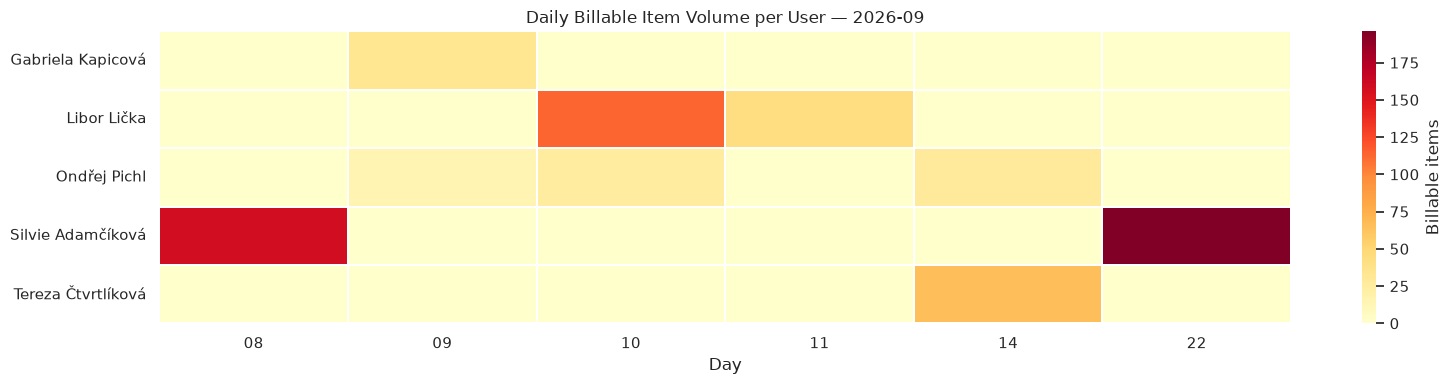

In [11]:
SQL_DAILY = f"""
SELECT
    {USER_NAME}               AS user_name,
    DATE(c.created_at)        AS day,
    COUNT(DISTINCT c.case_id) AS cases,
    COUNT(i.item_id)          AS billable_items
FROM case_item i
INNER JOIN "case" c ON c.case_id = i.case_id
LEFT  JOIN "user" u ON u.user_id = c.user_id
WHERE {BILLABLE}
  AND c.created_at >= %(period_from)s
  AND c.created_at <  %(period_to)s
  {ITEM_DELETED_FILTER}
  {CASE_DELETED_FILTER}
  {USER_FILTER}
GROUP BY user_name, DATE(c.created_at)
ORDER BY day, user_name;
"""

df_daily = query(SQL_DAILY, PERIOD)
df_daily['day'] = pd.to_datetime(df_daily['day']).dt.normalize()

pivot_daily = df_daily.pivot_table(index='user_name', columns='day', values='billable_items', fill_value=0)
pivot_daily.columns = pivot_daily.columns.strftime('%d')

fig, ax = plt.subplots(figsize=(16, max(4, len(pivot_daily) * 0.6)))
sns.heatmap(pivot_daily, cmap='YlOrRd', linewidths=0.3, ax=ax, cbar_kws={'label': 'Billable items'})
ax.set_title(f'Daily Billable Item Volume per User — {REPORT_YEAR}-{REPORT_MONTH:02d}')
ax.set_xlabel('Day'); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 7. Case Efficiency (items per case)

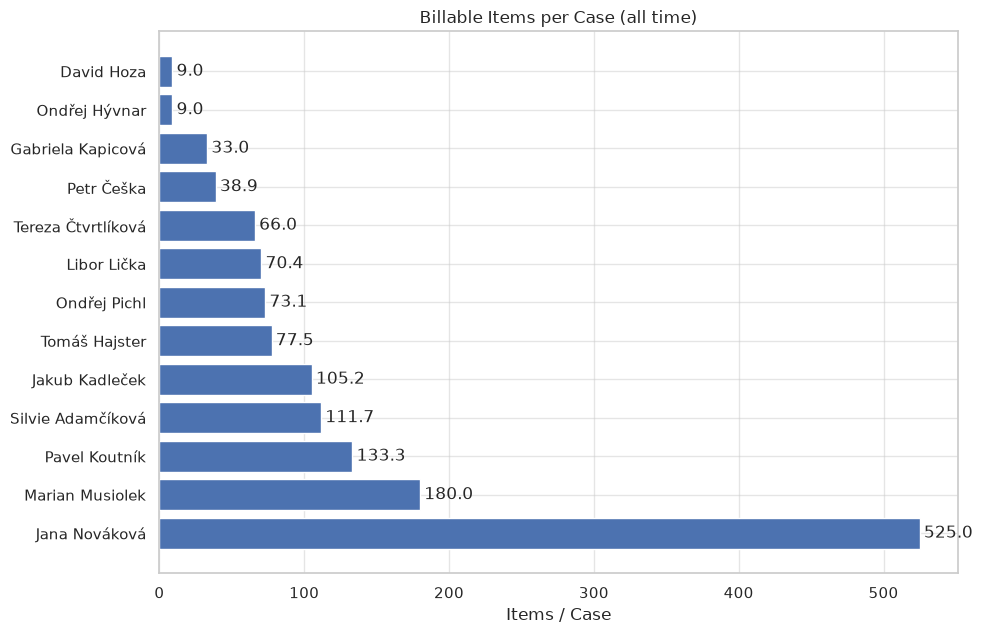

,user_name,cases,billable_items,items_per_case,smallest_case,largest_case,median_case_size,p95_case_size
0,Jana Nováková,1,525,525.0,525,525,525.0,525.0
1,Marian Musiolek,2,360,180.0,180,180,180.0,180.0
2,Pavel Koutník,3,400,133.3,71,204,125.0,196.1
3,Silvie Adamčíková,11,1229,111.7,21,539,68.0,343.5
4,Jakub Kadleček,22,2314,105.2,1,574,54.0,427.4
5,Tomáš Hajster,2,155,77.5,22,133,77.5,127.5
6,Ondřej Pichl,38,2779,73.1,1,886,21.0,200.8
7,Libor Lička,11,774,70.4,5,450,26.0,282.0
8,Tereza Čtvrtlíková,1,66,66.0,66,66,66.0,66.0
9,Petr Češka,11,428,38.9,2,124,25.0,96.0


In [12]:
# Aggregate per case first, so median/p95 are case-weighted
# (aggregating straight off item rows would weight each case by its own size).
SQL_EFFICIENCY = f"""
WITH per_case AS (
    SELECT
        {USER_NAME}      AS user_name,
        c.case_id,
        COUNT(i.item_id) AS items_in_case
    FROM "case" c
    INNER JOIN case_item i ON i.case_id = c.case_id AND {BILLABLE}
    LEFT  JOIN "user"    u ON u.user_id = c.user_id
    WHERE TRUE
      {ITEM_DELETED_FILTER}
      {CASE_DELETED_FILTER}
      {USER_FILTER}
    GROUP BY user_name, c.case_id
)
SELECT
    user_name,
    COUNT(*)           AS cases,
    SUM(items_in_case) AS billable_items,
    ROUND(SUM(items_in_case)::numeric / NULLIF(COUNT(*), 0), 1) AS items_per_case,
    MIN(items_in_case) AS smallest_case,
    MAX(items_in_case) AS largest_case,
    ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY items_in_case)::numeric, 1) AS median_case_size,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY items_in_case)::numeric, 1) AS p95_case_size
FROM per_case
GROUP BY user_name
ORDER BY items_per_case DESC;
"""

df_eff = query(SQL_EFFICIENCY)
for col in ('items_per_case', 'median_case_size', 'p95_case_size'):
    df_eff[col] = pd.to_numeric(df_eff[col], errors='coerce')

fig, ax = plt.subplots(figsize=(10, max(4, len(df_eff) * 0.5)))
bars = ax.barh(df_eff['user_name'], df_eff['items_per_case'])
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_title('Billable Items per Case (all time)'); ax.set_xlabel('Items / Case')
plt.tight_layout(); plt.show()
df_eff

## 8. Pareto — Top Users by Volume

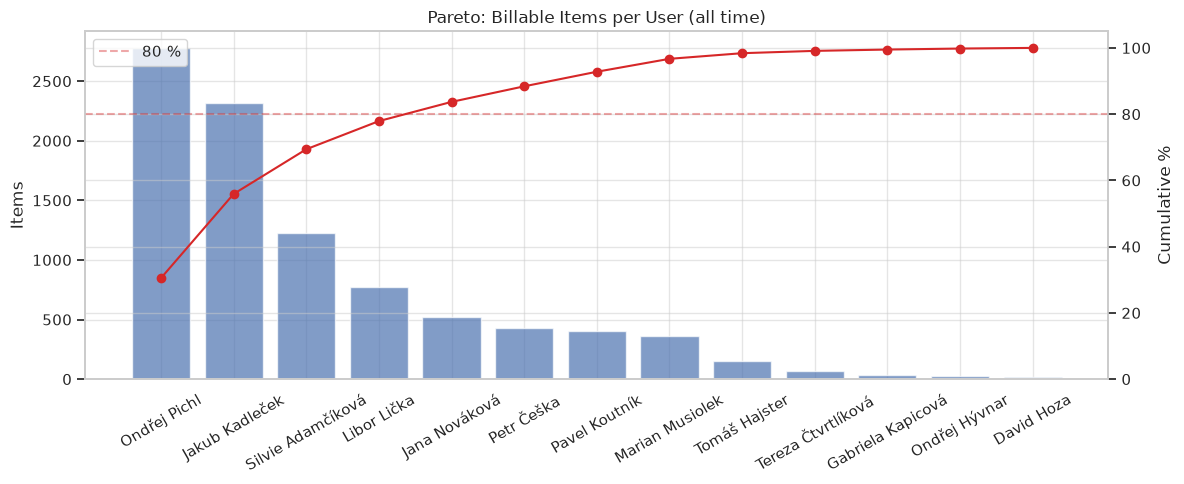

,rank,user_name,billable_items,pct_of_total,cumulative_pct
0,1,Ondřej Pichl,2779,30.5,30.5
1,2,Jakub Kadleček,2314,25.4,55.9
2,3,Silvie Adamčíková,1229,13.5,69.4
3,4,Libor Lička,774,8.5,77.9
4,5,Jana Nováková,525,5.8,83.7
5,6,Petr Češka,428,4.7,88.4
6,7,Pavel Koutník,400,4.4,92.8
7,8,Marian Musiolek,360,4.0,96.7
8,9,Tomáš Hajster,155,1.7,98.4
9,10,Tereza Čtvrtlíková,66,0.7,99.1


In [13]:
SQL_PARETO = f"""
WITH per_user AS (
    SELECT
        {USER_NAME}      AS user_name,
        COUNT(i.item_id) AS billable_items
    FROM case_item i
    INNER JOIN "case" c ON c.case_id = i.case_id
    LEFT  JOIN "user" u ON u.user_id = c.user_id
    WHERE {BILLABLE}
      {ITEM_DELETED_FILTER}
      {CASE_DELETED_FILTER}
      {USER_FILTER}
    GROUP BY user_name
),
ranked AS (
    SELECT
        user_name,
        billable_items,
        RANK() OVER (ORDER BY billable_items DESC) AS rank,
        ROUND(billable_items * 100.0 / SUM(billable_items) OVER (), 1) AS pct_of_total,
        ROUND(SUM(billable_items) OVER (ORDER BY billable_items DESC)
            * 100.0 / SUM(billable_items) OVER (), 1) AS cumulative_pct
    FROM per_user
)
SELECT rank, user_name, billable_items, pct_of_total, cumulative_pct
FROM ranked
ORDER BY rank;
"""

df_pareto = query(SQL_PARETO)
df_pareto['pct_of_total']   = pd.to_numeric(df_pareto['pct_of_total'],   errors='coerce')
df_pareto['cumulative_pct'] = pd.to_numeric(df_pareto['cumulative_pct'], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_pareto['user_name'], df_pareto['billable_items'], alpha=0.7)
ax2 = ax.twinx()
ax2.plot(df_pareto['user_name'], df_pareto['cumulative_pct'], color='tab:red', marker='o')
ax2.axhline(80, color='tab:red', linestyle='--', alpha=0.4, label='80 %')
ax.set_title('Pareto: Billable Items per User (all time)'); ax.set_ylabel('Items')
ax2.set_ylabel('Cumulative %'); ax2.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=30); ax2.legend()
plt.tight_layout(); plt.show()
df_pareto

## 9. Item Status Distribution

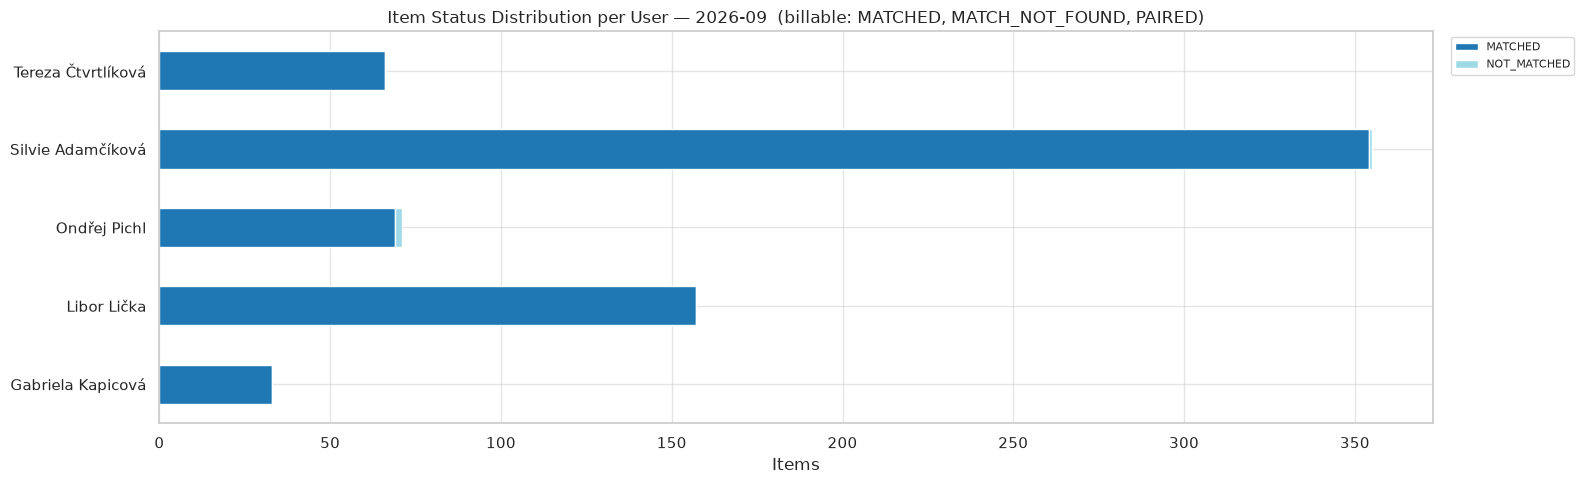

,user_name,status_id,status_name,is_billable,item_count,pct_of_user
0,Gabriela Kapicová,2,MATCHED,True,33,100.0
1,Libor Lička,2,MATCHED,True,157,100.0
2,Ondřej Pichl,2,MATCHED,True,69,97.2
3,Ondřej Pichl,3,NOT_MATCHED,False,2,2.8
4,Silvie Adamčíková,2,MATCHED,True,354,99.7
5,Silvie Adamčíková,3,NOT_MATCHED,False,1,0.3
6,Tereza Čtvrtlíková,2,MATCHED,True,66,100.0


In [14]:
SQL_STATUS_DIST = f"""
SELECT
    {USER_NAME}                 AS user_name,
    i.status_id,
    s.status_name,
    (i.status_id IN (2, 4, 5))  AS is_billable,
    COUNT(*)                    AS item_count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY {USER_NAME}), 1) AS pct_of_user
FROM case_item i
INNER JOIN "case"      c ON c.case_id   = i.case_id
INNER JOIN item_status s ON s.status_id = i.status_id
LEFT  JOIN "user"      u ON u.user_id   = c.user_id
WHERE c.created_at >= %(period_from)s
  AND c.created_at <  %(period_to)s
  {ITEM_DELETED_FILTER}
  {CASE_DELETED_FILTER}
  {USER_FILTER}
GROUP BY user_name, i.status_id, s.status_name
ORDER BY user_name, i.status_id;
"""

df_status = query(SQL_STATUS_DIST, PERIOD)
df_status['pct_of_user'] = pd.to_numeric(df_status['pct_of_user'], errors='coerce')

pivot_status = df_status.pivot_table(index='user_name', columns='status_name', values='item_count', fill_value=0)

fig, ax = plt.subplots(figsize=(16, max(5, len(pivot_status) * 0.6)))
pivot_status.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
ax.set_title(f'Item Status Distribution per User — {REPORT_YEAR}-{REPORT_MONTH:02d}  (billable: MATCHED, MATCH_NOT_FOUND, PAIRED)')
ax.set_xlabel('Items'); ax.set_ylabel('')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.show()
df_status

## 10. Matching Quality

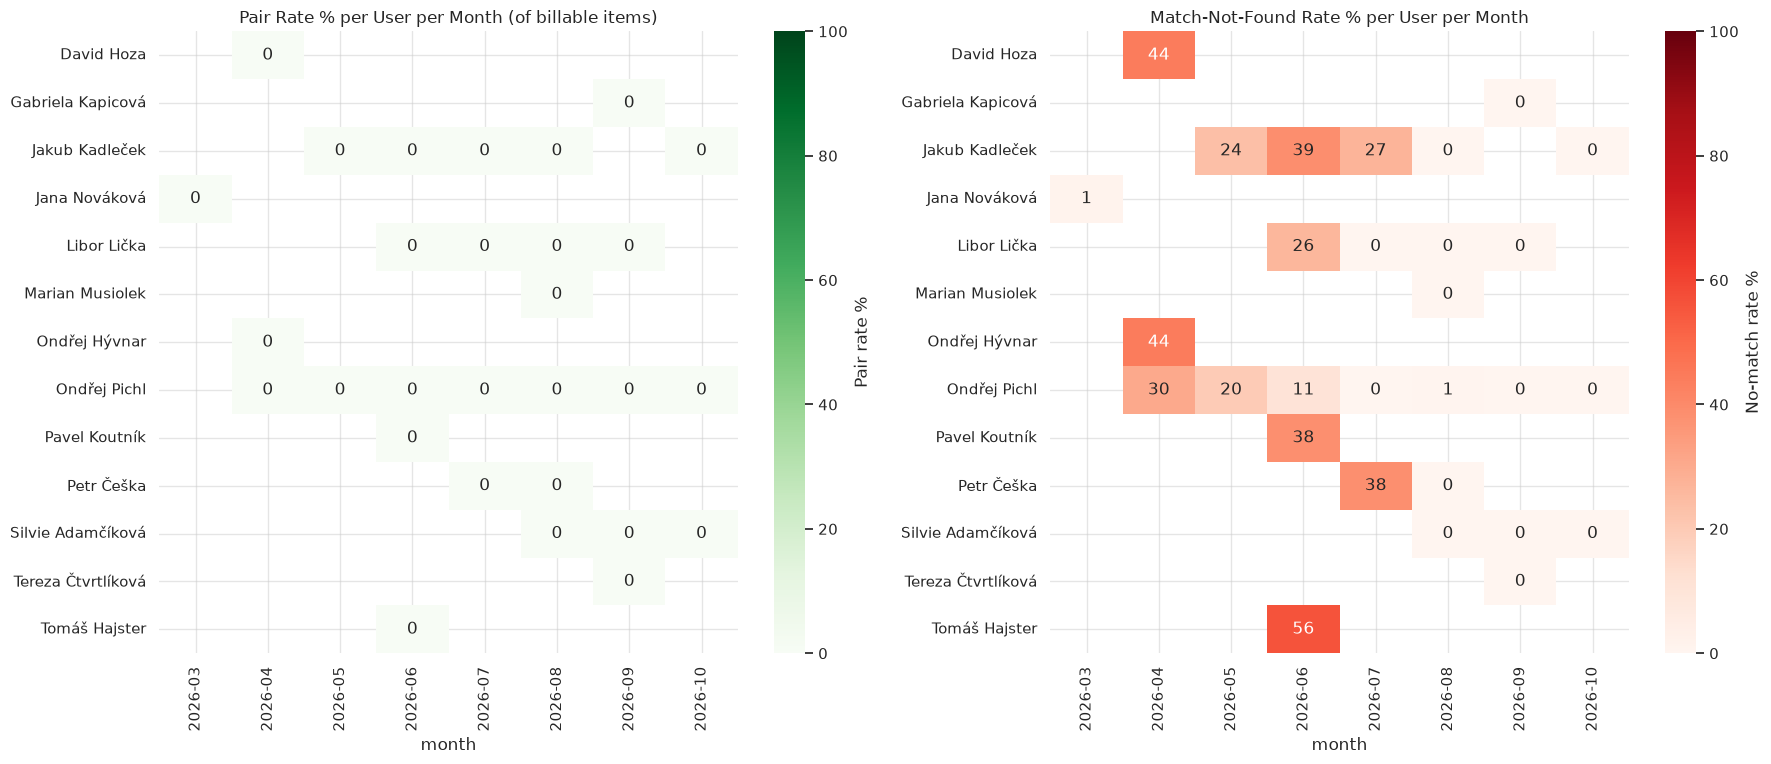

,user_name,month,billable_items,paired,matched_not_paired,match_not_found,not_matched_unbilled,still_created_unbilled,pair_rate_pct,no_match_rate_pct,exact_dimensions_pct
0,Jana Nováková,2026-03-01,525,0,518,7,0,0,0.0,1.3,98.7
1,David Hoza,2026-04-01,18,0,10,8,0,0,0.0,44.4,55.6
2,Ondřej Hývnar,2026-04-01,27,0,15,12,0,0,0.0,44.4,55.6
3,Ondřej Pichl,2026-04-01,1349,0,938,411,0,0,0.0,30.5,69.5
4,Jakub Kadleček,2026-05-01,126,0,96,30,0,0,0.0,23.8,76.2
5,Ondřej Pichl,2026-05-01,507,0,406,101,0,0,0.0,19.9,80.1
6,Jakub Kadleček,2026-06-01,206,0,126,80,0,0,0.0,38.8,61.2
7,Libor Lička,2026-06-01,72,0,53,19,0,0,0.0,26.4,73.6
8,Ondřej Pichl,2026-06-01,393,0,351,42,0,0,0.0,10.7,89.3
9,Pavel Koutník,2026-06-01,400,0,247,153,0,0,0.0,38.3,61.8


In [15]:
SQL_QUALITY = f"""
SELECT
    {USER_NAME}                       AS user_name,
    DATE_TRUNC('month', c.created_at) AS month,
    COUNT(*) FILTER (WHERE i.status_id IN (2, 4, 5)) AS billable_items,
    COUNT(*) FILTER (WHERE i.status_id = 5)          AS paired,
    COUNT(*) FILTER (WHERE i.status_id = 2)          AS matched_not_paired,
    COUNT(*) FILTER (WHERE i.status_id = 4)          AS match_not_found,
    COUNT(*) FILTER (WHERE i.status_id = 3)          AS not_matched_unbilled,
    COUNT(*) FILTER (WHERE i.status_id = 1)          AS still_created_unbilled,
    ROUND(COUNT(*) FILTER (WHERE i.status_id = 5) * 100.0
        / NULLIF(COUNT(*) FILTER (WHERE i.status_id IN (2, 4, 5)), 0), 1) AS pair_rate_pct,
    ROUND(COUNT(*) FILTER (WHERE i.status_id = 4) * 100.0
        / NULLIF(COUNT(*) FILTER (WHERE i.status_id IN (2, 4, 5)), 0), 1) AS no_match_rate_pct,
    ROUND(COUNT(*) FILTER (WHERE i.exact_dimensions_found) * 100.0
        / NULLIF(COUNT(*) FILTER (WHERE i.status_id IN (2, 4, 5)), 0), 1) AS exact_dimensions_pct
FROM case_item i
INNER JOIN "case" c ON c.case_id = i.case_id
LEFT  JOIN "user" u ON u.user_id = c.user_id
WHERE TRUE
  {ITEM_DELETED_FILTER}
  {CASE_DELETED_FILTER}
  {USER_FILTER}
GROUP BY user_name, DATE_TRUNC('month', c.created_at)
ORDER BY month, user_name;
"""

df_quality = query(SQL_QUALITY)
df_quality['month'] = pd.to_datetime(df_quality['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
for col in ('pair_rate_pct', 'no_match_rate_pct', 'exact_dimensions_pct'):
    df_quality[col] = pd.to_numeric(df_quality[col], errors='coerce')

pivot_pair    = df_quality.pivot_table(index='user_name', columns='month', values='pair_rate_pct')
pivot_nomatch = df_quality.pivot_table(index='user_name', columns='month', values='no_match_rate_pct')
pivot_pair.columns    = pivot_pair.columns.strftime('%Y-%m')
pivot_nomatch.columns = pivot_nomatch.columns.strftime('%Y-%m')

fig, axes = plt.subplots(1, 2, figsize=(18, max(4, len(pivot_pair) * 0.6)))
sns.heatmap(pivot_pair.astype(float), annot=True, fmt='.0f', cmap='Greens',
            ax=axes[0], cbar_kws={'label': 'Pair rate %'}, vmin=0, vmax=100)
axes[0].set_title('Pair Rate % per User per Month (of billable items)'); axes[0].set_ylabel('')
sns.heatmap(pivot_nomatch.astype(float), annot=True, fmt='.0f', cmap='Reds',
            ax=axes[1], cbar_kws={'label': 'No-match rate %'}, vmin=0, vmax=100)
axes[1].set_title('Match-Not-Found Rate % per User per Month'); axes[1].set_ylabel('')
plt.tight_layout(); plt.show()
df_quality

## 11. Case State Funnel

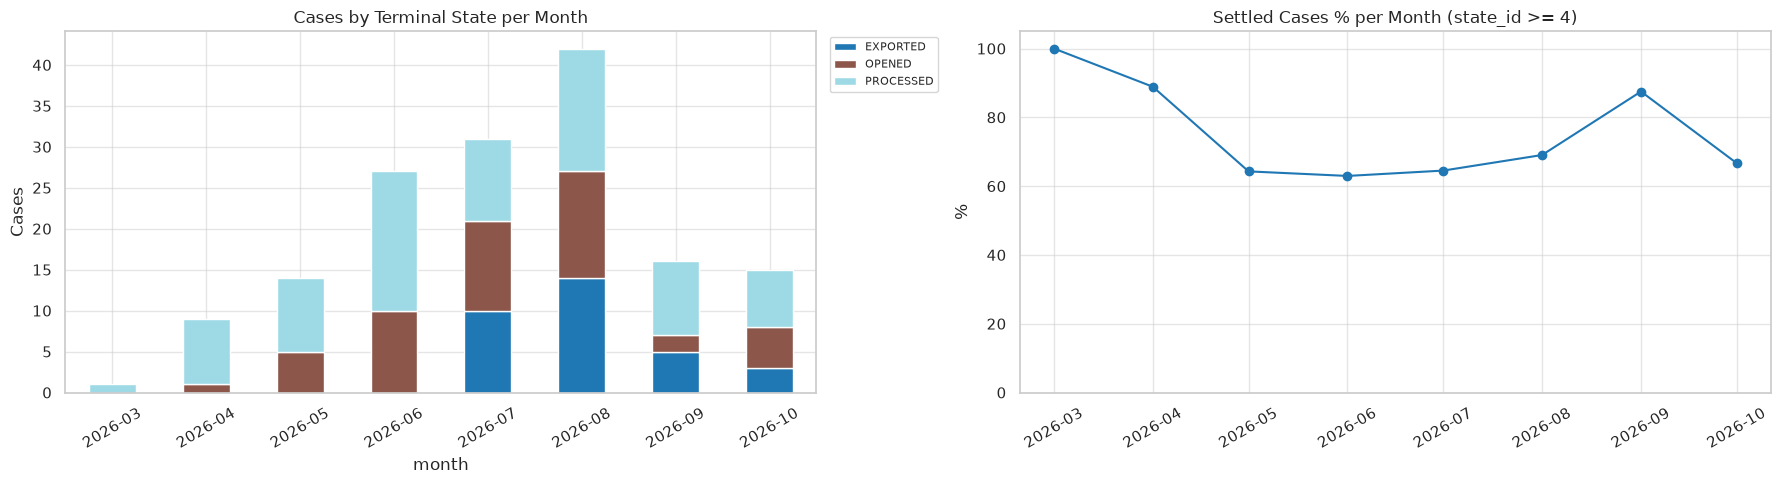

,month,state_id,state_name,is_settled,cases,pct_of_month,items_total,avg_pct_matched,avg_pct_done
0,2026-03-01,5,PROCESSED,True,1,100.0,525,100.0,0.0
1,2026-04-01,1,OPENED,False,1,11.1,0,0.0,0.0
2,2026-04-01,5,PROCESSED,True,8,88.9,1392,100.0,17.5
3,2026-05-01,1,OPENED,False,5,35.7,0,0.0,0.0
4,2026-05-01,5,PROCESSED,True,9,64.3,548,88.9,7.2
5,2026-06-01,1,OPENED,False,10,37.0,0,0.0,0.0
6,2026-06-01,5,PROCESSED,True,17,63.0,828,94.1,54.3
7,2026-07-01,1,OPENED,False,11,35.5,0,0.0,0.0
8,2026-07-01,5,PROCESSED,True,10,32.3,448,40.0,0.2
9,2026-07-01,6,EXPORTED,True,10,32.3,617,100.0,100.0


In [16]:
SQL_FUNNEL = f"""
SELECT
    DATE_TRUNC('month', c.created_at)   AS month,
    cs.state_id,
    cs.state_name,
    (cs.state_id >= {SETTLED_MIN_STATE}) AS is_settled,
    COUNT(*)                            AS cases,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY DATE_TRUNC('month', c.created_at)), 1) AS pct_of_month,
    SUM(c.items_total)                  AS items_total,
    ROUND(AVG(c.percentage_matched), 1) AS avg_pct_matched,
    ROUND(AVG(c.percentage_done), 1)    AS avg_pct_done
FROM "case" c
INNER JOIN case_state cs ON cs.state_id = c.state_id
WHERE TRUE
  {CASE_DELETED_FILTER}
  {USER_FILTER}
GROUP BY DATE_TRUNC('month', c.created_at), cs.state_id, cs.state_name
ORDER BY month, cs.state_id;
"""

df_funnel = query(SQL_FUNNEL)
df_funnel['month'] = pd.to_datetime(df_funnel['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
for col in ('pct_of_month', 'avg_pct_matched', 'avg_pct_done'):
    df_funnel[col] = pd.to_numeric(df_funnel[col], errors='coerce')

pivot_funnel = df_funnel.pivot_table(index='month', columns='state_name', values='cases', fill_value=0)
pivot_funnel.index = pivot_funnel.index.strftime('%Y-%m')

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
pivot_funnel.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
axes[0].set_title('Cases by Terminal State per Month'); axes[0].set_ylabel('Cases')
axes[0].tick_params(axis='x', rotation=30); axes[0].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

settled = df_funnel.groupby('month').apply(
    lambda g: 100.0 * g.loc[g.is_settled, 'cases'].sum() / max(g['cases'].sum(), 1)
)
axes[1].plot(settled.index, settled.values, marker='o', color='tab:blue')
axes[1].set_title('Settled Cases % per Month (state_id >= 4)'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 105); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
df_funnel

## 12. Processing Latency

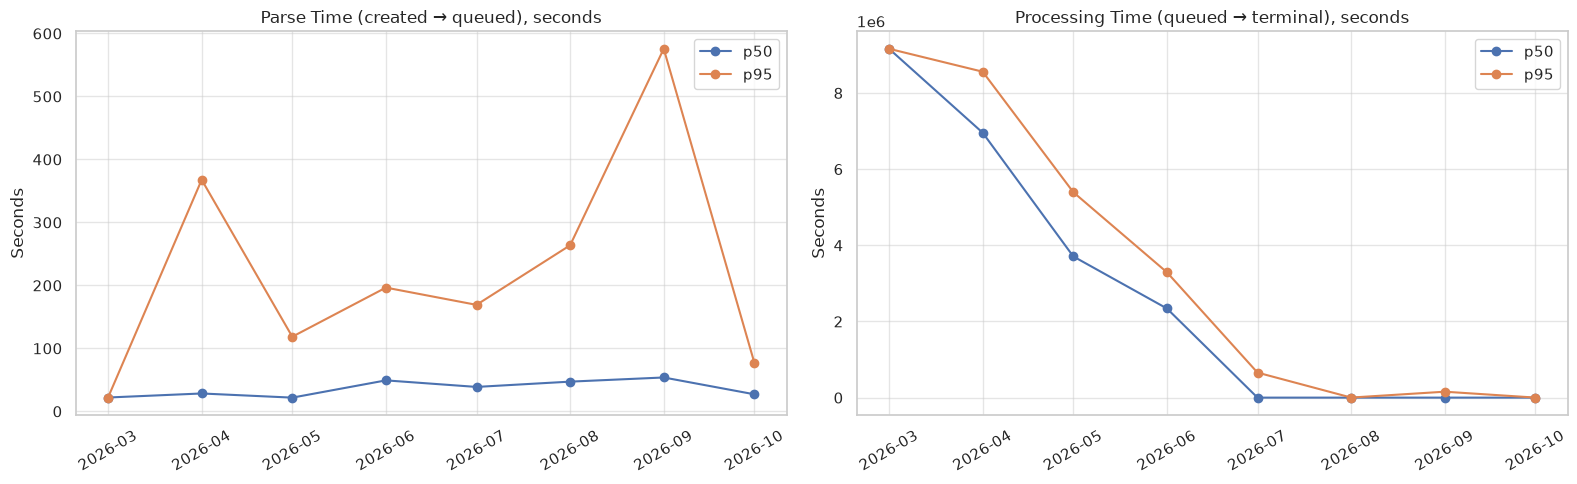

,month,cases,avg_parse_secs,p50_parse_secs,p95_parse_secs,avg_process_secs,p50_process_secs,p95_process_secs,avg_items_per_case
0,2026-03-01,1,22.0,22.0,22.0,9161127.1,9161127.1,9161127.1,525.0
1,2026-04-01,8,90.9,28.4,367.7,7232370.2,6956680.4,8558923.3,174.0
2,2026-05-01,9,40.2,21.8,118.5,4049118.6,3708505.2,5395699.6,60.9
3,2026-06-01,17,71.5,49.2,196.5,2224296.3,2341458.2,3292537.9,48.7
4,2026-07-01,20,62.0,38.8,169.1,194280.9,355.5,657660.7,53.3
5,2026-08-01,29,84.4,47.2,263.7,3185.0,417.6,2159.2,32.3
6,2026-09-01,14,159.4,53.8,575.7,31665.4,454.2,156038.9,36.6
7,2026-10-01,10,39.9,27.1,77.3,448.5,287.6,1378.6,18.7


In [17]:
SQL_LATENCY = f"""
SELECT
    DATE_TRUNC('month', c.created_at) AS month,
    COUNT(*)                          AS cases,
    ROUND(AVG(EXTRACT(EPOCH FROM (c.queued_at - c.created_at)))::numeric, 1) AS avg_parse_secs,
    ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY EXTRACT(EPOCH FROM (c.queued_at - c.created_at)))::numeric, 1) AS p50_parse_secs,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY EXTRACT(EPOCH FROM (c.queued_at - c.created_at)))::numeric, 1) AS p95_parse_secs,
    ROUND(AVG(EXTRACT(EPOCH FROM (c.last_modified - c.queued_at)))::numeric, 1) AS avg_process_secs,
    ROUND(PERCENTILE_CONT(0.5)  WITHIN GROUP (ORDER BY EXTRACT(EPOCH FROM (c.last_modified - c.queued_at)))::numeric, 1) AS p50_process_secs,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY EXTRACT(EPOCH FROM (c.last_modified - c.queued_at)))::numeric, 1) AS p95_process_secs,
    ROUND(AVG(c.items_total)::numeric, 1) AS avg_items_per_case
FROM "case" c
WHERE c.queued_at IS NOT NULL
  AND {SETTLED_STATE_FILTER}
  {CASE_DELETED_FILTER}
  {USER_FILTER}
GROUP BY DATE_TRUNC('month', c.created_at)
ORDER BY month;
"""

df_lat = query(SQL_LATENCY)
df_lat['month'] = pd.to_datetime(df_lat['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
lat_cols = ['avg_parse_secs', 'p50_parse_secs', 'p95_parse_secs',
            'avg_process_secs', 'p50_process_secs', 'p95_process_secs', 'avg_items_per_case']
for col in lat_cols:
    df_lat[col] = pd.to_numeric(df_lat[col], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(df_lat['month'], df_lat['p50_parse_secs'], marker='o', label='p50')
axes[0].plot(df_lat['month'], df_lat['p95_parse_secs'], marker='o', label='p95')
axes[0].set_title('Parse Time (created → queued), seconds'); axes[0].set_ylabel('Seconds'); axes[0].legend()
axes[1].plot(df_lat['month'], df_lat['p50_process_secs'], marker='o', label='p50')
axes[1].plot(df_lat['month'], df_lat['p95_process_secs'], marker='o', label='p95')
axes[1].set_title('Processing Time (queued → terminal), seconds'); axes[1].set_ylabel('Seconds'); axes[1].legend()
for ax in axes: ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
df_lat

## 13. Offer Depth & Match Distance

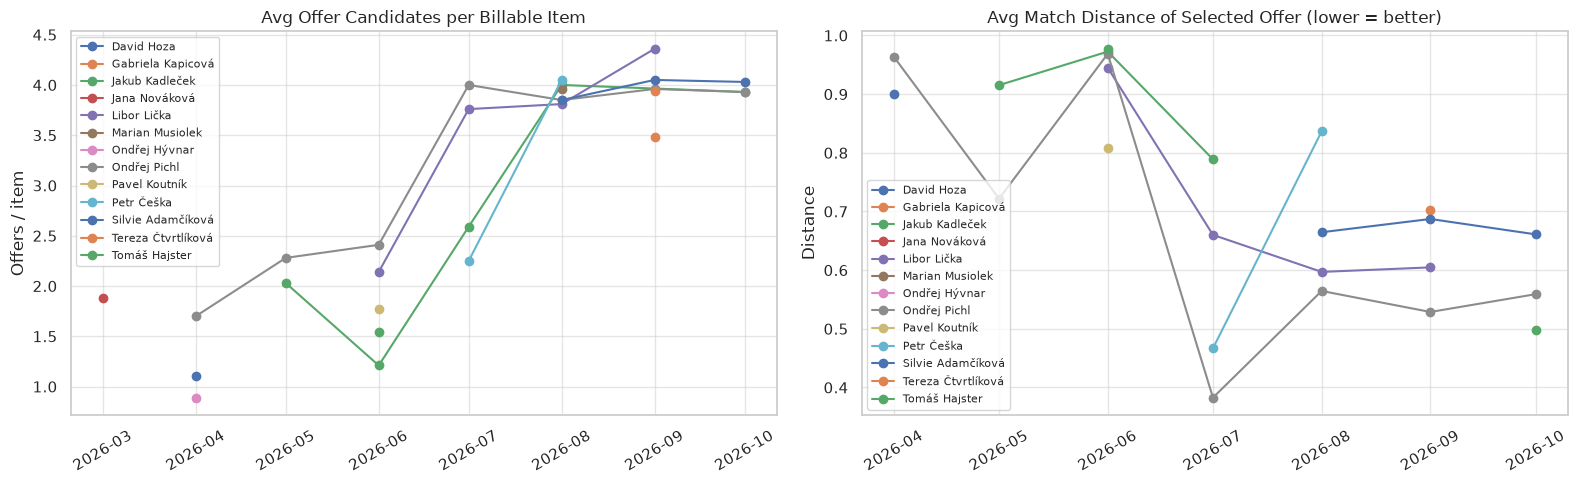

,user_name,month,billable_items,avg_offers_per_item,items_with_no_offer,items_with_selection,selection_rate_pct,avg_best_distance,avg_selected_distance,p50_selected_distance
0,Jana Nováková,2026-03-01,525,1.88,7,0,0.0,0.7662,NaN,NaN
1,David Hoza,2026-04-01,18,1.11,4,14,77.8,0.8000,0.9000,1.0000
2,Ondřej Hývnar,2026-04-01,27,0.89,12,0,0.0,0.8000,NaN,NaN
3,Ondřej Pichl,2026-04-01,1349,1.70,410,32,2.4,0.6163,0.9637,1.0000
4,Jakub Kadleček,2026-05-01,126,2.03,30,33,26.2,0.5642,0.9153,1.0000
5,Ondřej Pichl,2026-05-01,507,2.28,101,11,2.2,0.5899,0.7218,0.6667
6,Jakub Kadleček,2026-06-01,206,1.21,75,94,45.6,0.7666,0.9725,1.0000
7,Libor Lička,2026-06-01,72,2.14,19,33,45.8,0.6236,0.9449,1.0000
8,Ondřej Pichl,2026-06-01,393,2.41,38,146,37.2,0.6085,0.9687,1.0000
9,Pavel Koutník,2026-06-01,400,1.77,153,73,18.3,0.4925,0.8082,1.0000


In [18]:
SQL_OFFERS = f"""
WITH billable_items AS (
    SELECT
        {USER_NAME}                       AS user_name,
        DATE_TRUNC('month', c.created_at) AS month,
        i.item_id
    FROM case_item i
    INNER JOIN "case" c ON c.case_id = i.case_id
    LEFT  JOIN "user" u ON u.user_id = c.user_id
    WHERE {BILLABLE}
      {ITEM_DELETED_FILTER}
      {CASE_DELETED_FILTER}
      {USER_FILTER}
),
per_item AS (
    SELECT
        b.user_name,
        b.month,
        b.item_id,
        COUNT(o.offer_item_id)                              AS offers_offered,
        COUNT(o.offer_item_id) FILTER (WHERE o.is_selected) AS offers_selected,
        MIN(o.match_distance)                               AS best_distance,
        MIN(o.match_distance) FILTER (WHERE o.is_selected)  AS selected_distance
    FROM billable_items b
    LEFT JOIN offer_item o ON o.item_id = b.item_id
    GROUP BY b.user_name, b.month, b.item_id
)
SELECT
    user_name,
    month,
    COUNT(*)                                    AS billable_items,
    ROUND(AVG(offers_offered)::numeric, 2)      AS avg_offers_per_item,
    COUNT(*) FILTER (WHERE offers_offered = 0)  AS items_with_no_offer,
    COUNT(*) FILTER (WHERE offers_selected > 0) AS items_with_selection,
    ROUND(COUNT(*) FILTER (WHERE offers_selected > 0) * 100.0 / NULLIF(COUNT(*), 0), 1) AS selection_rate_pct,
    ROUND(AVG(best_distance)::numeric, 4)       AS avg_best_distance,
    ROUND(AVG(selected_distance)::numeric, 4)   AS avg_selected_distance,
    ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY selected_distance)::numeric, 4) AS p50_selected_distance
FROM per_item
GROUP BY user_name, month
ORDER BY month, user_name;
"""

df_offers = query(SQL_OFFERS)
df_offers['month'] = pd.to_datetime(df_offers['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
for col in ('avg_offers_per_item', 'selection_rate_pct', 'avg_best_distance',
            'avg_selected_distance', 'p50_selected_distance'):
    df_offers[col] = pd.to_numeric(df_offers[col], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for user, grp in df_offers.groupby('user_name'):
    axes[0].plot(grp['month'], grp['avg_offers_per_item'],   marker='o', label=user)
    axes[1].plot(grp['month'], grp['avg_selected_distance'], marker='o', label=user)
axes[0].set_title('Avg Offer Candidates per Billable Item'); axes[0].set_ylabel('Offers / item'); axes[0].legend(fontsize=8)
axes[1].set_title('Avg Match Distance of Selected Offer (lower = better)'); axes[1].set_ylabel('Distance'); axes[1].legend(fontsize=8)
for ax in axes: ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
df_offers

## 14. Accessory Attach Rate

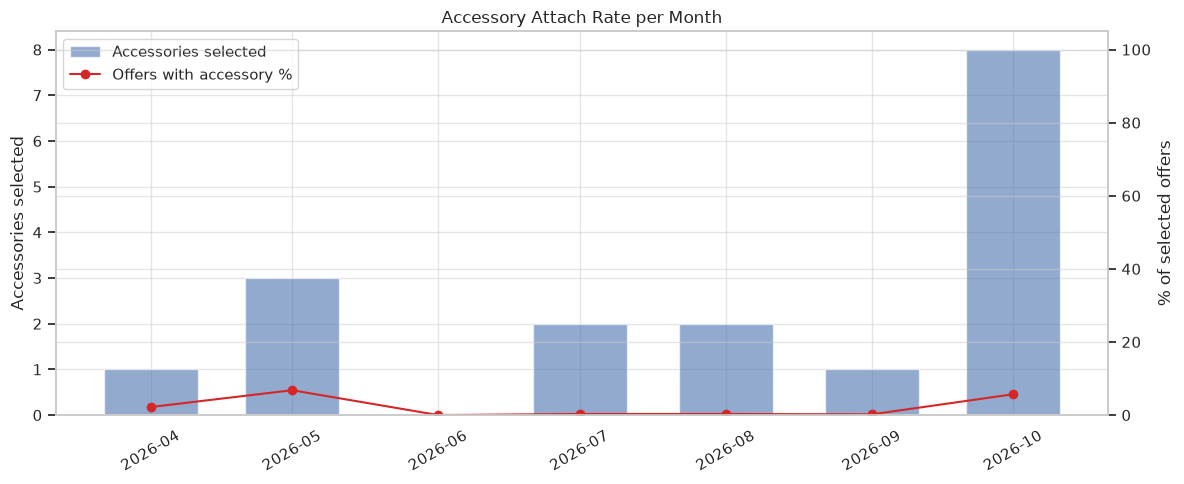

,month,selected_offers,accessories_offered,accessories_selected,accessory_qty_selected,offers_with_accessory_pct
0,2026-04-01,46,103,1,1.0,2.2
1,2026-05-01,44,131,3,49.0,6.8
2,2026-06-01,357,1870,0,NaN,0.0
3,2026-07-01,723,2311,2,12.0,0.3
4,2026-08-01,365,1214,2,2.0,0.3
5,2026-09-01,415,2643,1,17.0,0.2
6,2026-10-01,140,401,8,12.0,5.7


In [19]:
SQL_ACCESSORIES = f"""
SELECT
    DATE_TRUNC('month', c.created_at)                        AS month,
    COUNT(DISTINCT o.offer_item_id)                          AS selected_offers,
    COUNT(pa.accessory_id)                                   AS accessories_offered,
    COUNT(pa.accessory_id) FILTER (WHERE pa.is_selected)     AS accessories_selected,
    SUM(pa.accessory_quantity) FILTER (WHERE pa.is_selected) AS accessory_qty_selected,
    ROUND(COUNT(DISTINCT o.offer_item_id) FILTER (WHERE pa.is_selected) * 100.0
        / NULLIF(COUNT(DISTINCT o.offer_item_id), 0), 1)     AS offers_with_accessory_pct
FROM "case" c
INNER JOIN case_item  i ON i.case_id = c.case_id AND {BILLABLE}
INNER JOIN offer_item o ON o.item_id = i.item_id AND o.is_selected = TRUE
LEFT  JOIN product_accessory pa ON pa.offer_item_id = o.offer_item_id
WHERE TRUE
  {ITEM_DELETED_FILTER}
  {CASE_DELETED_FILTER}
  {USER_FILTER}
GROUP BY DATE_TRUNC('month', c.created_at)
ORDER BY month;
"""

df_acc = query(SQL_ACCESSORIES)
df_acc['month'] = pd.to_datetime(df_acc['month'], utc=True).dt.normalize().dt.tz_localize(None) + pd.offsets.MonthBegin(0)
df_acc['offers_with_accessory_pct'] = pd.to_numeric(df_acc['offers_with_accessory_pct'], errors='coerce')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_acc['month'], df_acc['accessories_selected'], width=20, alpha=0.6, label='Accessories selected')
ax2 = ax.twinx()
ax2.plot(df_acc['month'], df_acc['offers_with_accessory_pct'], color='tab:red', marker='o', label='Offers with accessory %')
ax.set_title('Accessory Attach Rate per Month')
ax.set_ylabel('Accessories selected'); ax2.set_ylabel('% of selected offers')
ax2.set_ylim(0, 105); ax.tick_params(axis='x', rotation=30)
l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left')
plt.tight_layout(); plt.show()
df_acc

## 15. Export to PDF

In [20]:
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

PDF_PATH = f'aquila_statistics_{REPORT_YEAR}_{REPORT_MONTH:02d}.pdf'

def _fig(*args, **kwargs):
    return plt.subplots(*args, **{**{'figsize': (14, 6)}, **kwargs})

def _fmt(val):
    """Format a cell value: numbers get thousands separator, strings stay as-is."""
    try:
        n = float(val)
        if n == int(n):
            return f'{int(n):,}'
        return f'{n:,.2f}'
    except (TypeError, ValueError):
        return str(val) if val is not None else ''

with PdfPages(PDF_PATH) as pdf:

    # ── Cover page ────────────────────────────────────────
    fig, ax = _fig()
    ax.axis('off')
    ax.text(0.5, 0.68, 'Aquila Statistics Report',
            ha='center', va='center', fontsize=28, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.56, 'System Air',
            ha='center', va='center', fontsize=16, transform=ax.transAxes)
    ax.text(0.5, 0.46, f'Period: {REPORT_YEAR}-{REPORT_MONTH:02d}',
            ha='center', va='center', fontsize=18, transform=ax.transAxes)
    ax.text(0.5, 0.36, f'Generated: {datetime.today().strftime("%Y-%m-%d")}',
            ha='center', va='center', fontsize=13, color='grey', transform=ax.transAxes)
    ax.text(0.5, 0.28, f'Billable items: case_item.status_id IN {BILLABLE_STATUSES}  |  {UNIT_PRICE_EUR:g} EUR / item',
            ha='center', va='center', fontsize=10, color='grey', transform=ax.transAxes)
    ax.text(0.5, 0.22, f'+ {AZURE_INFRA_FEE_EUR:,.0f} EUR Azure Cloud Infrastructure fee / month'
                       f'   |   1 EUR = {EUR_TO_CZK_CURRECY_RATE:g} CZK',
            ha='center', va='center', fontsize=10, color='grey', transform=ax.transAxes)
    ax.text(0.5, 0.14, f'Invoice total: {total_eur:,.2f} EUR   ({total_eur * EUR_TO_CZK_CURRECY_RATE:,.2f} CZK)',
            ha='center', va='center', fontsize=13, fontweight='bold', transform=ax.transAxes)
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 1. Current month summary table ─────────────────────────
    col_align = ['left', 'left', 'right', 'right', 'right', 'right']   # per column

    fmt_rows = [[_fmt(v) for v in row] for row in df_summary.values]

    fig, ax = _fig(figsize=(14, max(3, len(df_summary) * 0.45)))
    ax.axis('off')
    tbl = ax.table(cellText=fmt_rows, colLabels=df_summary.columns, loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.5)

    n_rows = len(fmt_rows)

    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')
            cell.set_edgecolor('white')
        elif row == n_rows:                      # ZZ TOTAL row
            cell.set_facecolor('#d5dbdb')
            cell.set_text_props(fontweight='bold')
            cell.set_edgecolor('#bdc3c7')
        elif row >= n_rows - 2:                  # subtotal + Azure fee rows
            cell.set_facecolor('#ecf0f1')
            cell.set_edgecolor('#bdc3c7')
        else:
            cell.set_facecolor('#ffffff' if row % 2 == 0 else '#f8f9fa')
            cell.set_edgecolor('#dee2e6')
        cell.get_text().set_ha(col_align[col] if col < len(col_align) else 'right')
        if col > 1:
            cell.PAD = 0.08

    ax.set_title(f'Current Month Summary — {REPORT_YEAR}-{REPORT_MONTH:02d}',
                 fontsize=14, fontweight='bold', pad=16)
    pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 2. Items & amount bar charts ──────────────────────────
    fig, axes = _fig(1, 3, figsize=(18, 5))
    axes[0].barh(users.user_name, users.billable_items)
    axes[0].set_title(f'Billable Items — {REPORT_YEAR}-{REPORT_MONTH:02d}'); axes[0].set_xlabel('Items')
    axes[1].barh(users.user_name, users.amount_eur)
    axes[1].set_title(f'Item Charges (EUR) — {REPORT_YEAR}-{REPORT_MONTH:02d}'); axes[1].set_xlabel('EUR')
    axes[2].bar(['Items', 'Azure fee'], [items_eur, AZURE_INFRA_FEE_EUR], color=['tab:blue', 'tab:orange'])
    axes[2].bar_label(axes[2].containers[0], fmt='%.2f', padding=3)
    axes[2].set_title(f'Monthly Cost Split — total {total_eur:,.2f} EUR'); axes[2].set_ylabel('EUR')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 3. MoM growth heatmap ───────────────────────────────
    fig, ax = _fig(figsize=(14, max(4, len(pivot_mom) * 0.6)))
    sns.heatmap(pivot_mom.astype(float), annot=True, fmt='.0f', center=0, cmap='RdYlGn',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Item growth %'})
    ax.set_title('Month-over-Month Consumption Growth % per User'); ax.set_ylabel(''); ax.set_xlabel('')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 4. Consumption trend lines ───────────────────────────
    fig, axes = _fig(1, 2, figsize=(16, 5))
    for user, grp in df_trend.groupby('user_name'):
        axes[0].plot(grp['month'], grp['billable_items'], marker='o', label=user)
        axes[1].plot(grp['month'], grp['amount_eur'],     marker='o', label=user)
    axes[0].set_title('Billable Items per Month per User'); axes[0].set_ylabel('Items'); axes[0].legend(fontsize=7)
    axes[1].set_title('Item Charges (EUR) per Month per User — excl. Azure fee'); axes[1].set_ylabel('EUR')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.2f}')); axes[1].legend(fontsize=7)
    for ax in axes: ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 5. Cumulative YTD ─────────────────────────────────
    fig, ax = _fig(figsize=(12, 5))
    ax.bar(df_cum['month'], df_cum['items_amount_eur'], width=20, alpha=0.8, label='Item charges')
    ax.bar(df_cum['month'], df_cum['azure_fee_eur'], width=20, alpha=0.8,
           bottom=df_cum['items_amount_eur'], label='Azure infra fee')
    ax2 = ax.twinx()
    ax2.plot(df_cum['month'], df_cum['cumulative_eur'], color='tab:red', marker='o', label='Cumulative YTD')
    ax.set_title(f'Monthly & Cumulative YTD Cost {REPORT_YEAR} (EUR)')
    ax.set_ylabel('Monthly (EUR)'); ax2.set_ylabel('Cumulative (EUR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='x', rotation=30)
    l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, loc='upper left')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 6. Daily heatmap ──────────────────────────────────
    fig, ax = _fig(figsize=(16, max(4, len(pivot_daily) * 0.6)))
    sns.heatmap(pivot_daily, cmap='YlOrRd', linewidths=0.3, ax=ax, cbar_kws={'label': 'Billable items'})
    ax.set_title(f'Daily Billable Item Volume per User — {REPORT_YEAR}-{REPORT_MONTH:02d}')
    ax.set_xlabel('Day'); ax.set_ylabel(''); ax.tick_params(axis='x', rotation=0)
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 7. Case efficiency ─────────────────────────────────
    fig, ax = _fig(figsize=(10, max(4, len(df_eff) * 0.5)))
    bars = ax.barh(df_eff['user_name'], df_eff['items_per_case'])
    ax.bar_label(bars, fmt='%.1f', padding=3)
    ax.set_title('Billable Items per Case (all time)'); ax.set_xlabel('Items / Case')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 8. Pareto ───────────────────────────────────────
    fig, ax = _fig(figsize=(12, 5))
    ax.bar(df_pareto['user_name'], df_pareto['billable_items'], alpha=0.7)
    ax2 = ax.twinx()
    ax2.plot(df_pareto['user_name'], df_pareto['cumulative_pct'], color='tab:red', marker='o')
    ax2.axhline(80, color='tab:red', linestyle='--', alpha=0.4, label='80 %')
    ax.set_title('Pareto: Billable Items per User (all time)'); ax.set_ylabel('Items')
    ax2.set_ylabel('Cumulative %'); ax2.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=30); ax2.legend()
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 9. Item status distribution ──────────────────────────
    fig, ax = _fig(figsize=(16, max(5, len(pivot_status) * 0.6)))
    pivot_status.plot(kind='barh', stacked=True, ax=ax, colormap='tab20')
    ax.set_title(f'Item Status Distribution per User — {REPORT_YEAR}-{REPORT_MONTH:02d}')
    ax.set_xlabel('Items'); ax.set_ylabel('')
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 10. Matching quality ───────────────────────────────
    fig, axes = _fig(1, 2, figsize=(18, max(4, len(pivot_pair) * 0.6)))
    sns.heatmap(pivot_pair.astype(float), annot=True, fmt='.0f', cmap='Greens',
                ax=axes[0], cbar_kws={'label': 'Pair rate %'}, vmin=0, vmax=100)
    axes[0].set_title('Pair Rate % per User per Month'); axes[0].set_ylabel('')
    sns.heatmap(pivot_nomatch.astype(float), annot=True, fmt='.0f', cmap='Reds',
                ax=axes[1], cbar_kws={'label': 'No-match rate %'}, vmin=0, vmax=100)
    axes[1].set_title('Match-Not-Found Rate % per User per Month'); axes[1].set_ylabel('')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 11. Case state funnel ──────────────────────────────
    fig, axes = _fig(1, 2, figsize=(18, 5))
    pivot_funnel.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20')
    axes[0].set_title('Cases by Terminal State per Month'); axes[0].set_ylabel('Cases')
    axes[0].tick_params(axis='x', rotation=30); axes[0].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    axes[1].plot(settled.index, settled.values, marker='o', color='tab:blue')
    axes[1].set_title('Settled Cases % per Month (state_id >= 4)'); axes[1].set_ylabel('%')
    axes[1].set_ylim(0, 105); axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 12. Processing latency ─────────────────────────────
    fig, axes = _fig(1, 2, figsize=(16, 5))
    axes[0].plot(df_lat['month'], df_lat['p50_parse_secs'], marker='o', label='p50')
    axes[0].plot(df_lat['month'], df_lat['p95_parse_secs'], marker='o', label='p95')
    axes[0].set_title('Parse Time (created → queued), seconds'); axes[0].set_ylabel('Seconds'); axes[0].legend()
    axes[1].plot(df_lat['month'], df_lat['p50_process_secs'], marker='o', label='p50')
    axes[1].plot(df_lat['month'], df_lat['p95_process_secs'], marker='o', label='p95')
    axes[1].set_title('Processing Time (queued → terminal), seconds'); axes[1].set_ylabel('Seconds'); axes[1].legend()
    for ax in axes: ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 13. Offer depth & match distance ───────────────────────
    fig, axes = _fig(1, 2, figsize=(16, 5))
    for user, grp in df_offers.groupby('user_name'):
        axes[0].plot(grp['month'], grp['avg_offers_per_item'],   marker='o', label=user)
        axes[1].plot(grp['month'], grp['avg_selected_distance'], marker='o', label=user)
    axes[0].set_title('Avg Offer Candidates per Billable Item'); axes[0].set_ylabel('Offers / item'); axes[0].legend(fontsize=7)
    axes[1].set_title('Avg Match Distance of Selected Offer (lower = better)'); axes[1].set_ylabel('Distance'); axes[1].legend(fontsize=7)
    for ax in axes: ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    # ── 14. Accessory attach rate ───────────────────────────
    fig, ax = _fig(figsize=(12, 5))
    ax.bar(df_acc['month'], df_acc['accessories_selected'], width=20, alpha=0.6, label='Accessories selected')
    ax2 = ax.twinx()
    ax2.plot(df_acc['month'], df_acc['offers_with_accessory_pct'], color='tab:red', marker='o', label='Offers with accessory %')
    ax.set_title('Accessory Attach Rate per Month')
    ax.set_ylabel('Accessories selected'); ax2.set_ylabel('% of selected offers')
    ax2.set_ylim(0, 105); ax.tick_params(axis='x', rotation=30)
    l1, lb1 = ax.get_legend_handles_labels(); l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, lb1+lb2, loc='upper left')
    plt.tight_layout(); pdf.savefig(fig, bbox_inches='tight'); plt.close(fig)

    pdf.infodict()['Title']   = f'Aquila Statistics {REPORT_YEAR}-{REPORT_MONTH:02d}'
    pdf.infodict()['Author']  = 'Granton AI'
    pdf.infodict()['Subject'] = 'System Air — Board Report'

print(f'Saved → {PDF_PATH} (14 sections)')

Saved → aquila_statistics_2026_09.pdf (14 sections)
